Im currently attending CU Boulder, so in light of that instead of doing California housing prices, lets do some in Denver Colorado! (Coulndn't find a Boulder one lol) 
Ok this is future Nevan we found not only Colorado, but Boulder in this dataset Ws

In [45]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor

In [28]:

path = kagglehub.dataset_download("paultimothymooney/zillow-house-price-data") +r"/City_Zhvi_AllHomes.csv"
df = pd.read_csv(path)


In [29]:
print(df.columns[:10])
co = df[df["State"] == "CO"]
denver_boulder = co[co["RegionName"].isin(["Denver", "Boulder"])]

print(denver_boulder[["RegionID", "RegionName", "State", "Metro", "CountyName"]])

Index(['Unnamed: 0', 'RegionID', 'SizeRank', 'RegionName', 'RegionType',
       'StateName', 'State', 'Metro', 'CountyName', '1996-01-31'],
      dtype='str')
     RegionID RegionName State                   Metro      CountyName
23      11093     Denver    CO  Denver-Aurora-Lakewood   Denver County
259     30543    Boulder    CO                 Boulder  Boulder County


In [30]:
date_cols = [c for c in denver_boulder.columns if c[0].isdigit()]
id_cols = [c for c in denver_boulder.columns if c not in date_cols]

long_df = denver_boulder.melt(
    id_vars=id_cols,
    value_vars=date_cols,
    var_name="Date",
    value_name="Zhvi"
)
long_df["Date"] = pd.to_datetime(long_df["Date"])

Okay so for this I decided let's look at the Dataset's graph first!

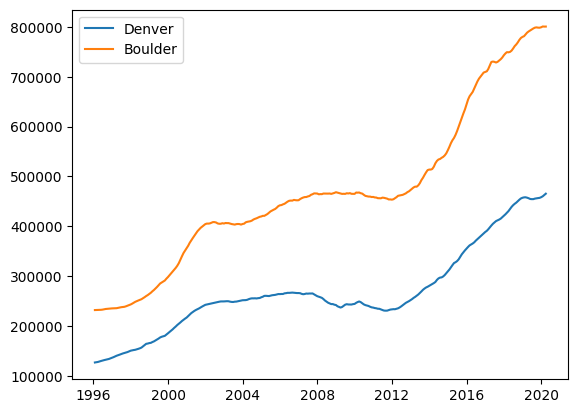

In [31]:
for city in ["Denver", "Boulder"]:
    subset = long_df[long_df["RegionName"] == city].sort_values("Date")
    plt.plot(subset["Date"], subset["Zhvi"], label=city)
plt.legend()
plt.show()

In [ ]:
long_df = long_df.sort_values(["RegionName", "Date"])
long_df["pct_change"] = long_df.groupby("RegionName")["Zhvi"].pct_change()

for lag in [1, 3, 6, 12]:
    long_df[f"pct_change_lag_{lag}"] = long_df.groupby("RegionName")["pct_change"].shift(lag)

feature_cols = [f"pct_change_lag_{lag}" for lag in [1, 3, 6, 12]]
model_df = long_df.dropna(subset=["pct_change"] + feature_cols)

Ok so we're gonna train test split this differently, instead of doing 80/20 like we usually do I want to split this to pre 2015 data as the training set and post 2015 data as the test set

In [36]:
train = model_df[model_df["Date"] < "2015-01-01"]
test = model_df[model_df["Date"] >= "2015-01-01"]

X_train, y_train  = train[feature_cols], train["pct_change"]
X_test, y_test = test[feature_cols], test["pct_change"]

What if we made a naive model...

In [42]:
naive_pred = X_test["pct_change_lag_1"]
naive_rmse = mean_squared_error(y_test, naive_pred) ** 0.5

It's basically telling us "this month's change will equal last month's change", which is almost never the case with housing prices

In [43]:
print("Naive RMSE:", naive_rmse)

Naive RMSE: 0.0020906937214606623


In [46]:
model = XGBRegressor(n_estimators=300, random_state=42, eval_metric='rmse')
model.fit(X_train, y_train)
model_rmse = mean_squared_error(y_test, model.predict(X_test)) ** 0.5
print("Model RMSE:", model_rmse)

Model RMSE: 0.0022278214324814413
